# Financial Data Group Project

Before starting the project, making sure Python and those dependencies has already been installed in your machine.

Highly recommend to install virtual environment for installing those dependencies. The dependencies list are mentioned under requirements.txt

## Import required dependencies

In [1]:
import numpy as np
import pandas as pd
import pandas_ta_classic as ta
import yfinance as yf
from matplotlib import pyplot as plt
from sklearn.metrics import accuracy_score
from sklearn.model_selection import StratifiedKFold
from sklearn.neural_network import MLPClassifier
from sklearn.preprocessing import MinMaxScaler


In [2]:
print(pd.__version__)
print(ta.version)

3.0.3
0.6.52


## Part 1: Assessing Models with Alternative Data

In this part we analyze **IVV** (iShares Core S&P 500 ETF), following Sagaceta-Mejía et al. (econ-2022-0073).


### Download IVV data from relevant time interval

Paper window: **2009-12-12 → 2020-01-01**. Use `auto_adjust=False` so **Open** matches Yahoo raw prices (paper Table 2), not dividend-adjusted levels.


In [3]:
# Load IVV from Yahoo Finance (raw OHLC; matches paper Table 2)
ticker = "IVV"
start_date = "2009-12-12"
end_date = "2020-01-01"

df = yf.download(ticker, start=start_date, end=end_date, auto_adjust=False)
df.head(10)


[*********************100%***********************]  1 of 1 completed


Price,Adj Close,Close,High,Low,Open,Volume
Ticker,IVV,IVV,IVV,IVV,IVV,IVV
Date,,,,,,
2009-12-14,83.156837,112.230003,112.360001,111.730003,112.250000,3201000
2009-12-15,82.756737,111.690002,112.290001,111.370003,111.849998,2537100
2009-12-16,82.912323,111.900002,112.489998,111.650002,112.180000,2842400
2009-12-17,81.860199,110.480003,111.269997,110.440002,111.080002,7247700
2009-12-18,82.378860,111.180000,111.250000,110.220001,111.139999,4320400
2009-12-21,83.142036,112.209999,112.650002,111.690002,111.699997,2675400
2009-12-22,83.468071,112.650002,113.000000,112.379997,112.519997,2204700
2009-12-23,83.675529,112.930000,113.059998,112.470001,113.029999,5763500


In [4]:
# Flatten MultiIndex columns from yfinance, then compute Pandas-TA indicators
if isinstance(df.columns, pd.MultiIndex):
    df.columns = [
        "_".join([str(col) for col in multi_col if col]).strip()
        for multi_col in df.columns
    ]
df.ta.cores = 0  # avoid multiprocessing issues in notebooks
df.ta.strategy("All")


In [5]:
df

,Adj Close_IVV,Close_IVV,High_IVV,Low_IVV,Open_IVV,Volume_IVV,ABER_ZG_5_15,ABER_SG_5_15,ABER_XG_5_15,ABER_ATR_5_15,...,VWMA_10,VWMACD_12_26_9,VWMACDh_12_26_9,VWMACDs_12_26_9,WAD,WCP,WILLR_14,WMA_10,ZL_EMA_10,ZS_30
Date,,,,,,,,,,,,,,,,,,,,,
2009-12-14,83.156837,112.230003,112.360001,111.730003,112.250000,3201000,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,0.000000,112.137503,NaN,NaN,NaN,NaN
2009-12-15,82.756737,111.690002,112.290001,111.370003,111.849998,2537100,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,-0.599998,111.760002,NaN,NaN,NaN,NaN
2009-12-16,82.912323,111.900002,112.489998,111.650002,112.180000,2842400,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,-0.349998,111.985001,NaN,NaN,NaN,NaN
2009-12-17,81.860199,110.480003,111.269997,110.440002,111.080002,7247700,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,-1.769997,110.667501,NaN,NaN,NaN,NaN
2009-12-18,82.378860,111.180000,111.250000,110.220001,111.139999,4320400,111.503335,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,-0.809998,110.957500,NaN,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2019-12-24,293.119019,322.649994,322.929993,322.309998,322.869995,2716300,321.547331,323.384465,319.710197,1.837134,...,320.028711,2.370221,0.536349,1.833872,312.550011,322.634995,-6.363747,321.014723,322.710887,1.883015
2019-12-26,294.636139,324.320007,324.329987,323.019989,323.059998,2847400,322.405998,324.232656,320.579340,1.826658,...,320.728789,2.559756,0.658368,1.901388,314.220024,323.997498,-0.102667,321.788543,323.654366,2.113234
2019-12-27,294.581635,324.260010,325.190002,323.709991,325.190002,5091400,323.223999,325.027547,321.420451,1.803548,...,321.350678,2.757689,0.718200,2.039489,313.290031,324.355003,-8.790087,322.403273,324.106302,1.917020


In [6]:
# convert index to date time
df.index = pd.to_datetime(df.index)
df.index

DatetimeIndex(['2009-12-14', '2009-12-15', '2009-12-16', '2009-12-17',
               '2009-12-18', '2009-12-21', '2009-12-22', '2009-12-23',
               '2009-12-24', '2009-12-28',
               ...
               '2019-12-17', '2019-12-18', '2019-12-19', '2019-12-20',
               '2019-12-23', '2019-12-24', '2019-12-26', '2019-12-27',
               '2019-12-30', '2019-12-31'],
              dtype='datetime64[s]', name='Date', length=2529, freq=None)

### Open Values Analysis

#### Basic data summary 


In [7]:
open_values = df['Open_IVV']

minimum = np.min(open_values)
q1 = np.percentile(open_values, 25)      # 1st quartile (25th percentile)
median = np.median(open_values)          # 50th percentile 
mean = np.mean(open_values)
q3 = np.percentile(open_values, 75)      # 3rd quartile (75th percentile)
maximum = np.max(open_values)

df_stats = pd.DataFrame.from_dict({
    "Minimum": round(minimum, 1), 
    "1st Quartile": round(q1, 1), 
    "Median": round(median, 1),
    "Mean": round(mean, 1), 
    "3rd Quartile": round(q3, 1), 
    "Maximum": round(maximum, 1), 
}, orient="index")

df_stats.columns = [ticker]

In [8]:
df_stats

,IVV
Minimum,103.5
1st Quartile,138.3
Median,199.4
Mean,197.0
3rd Quartile,244.8
Maximum,325.2


Our Open summary (rounded to 1 d.p.) matches paper **Table 2** for IVV closely:

| Stat | Ours | Paper Table 2 |
|---|---:|---:|
| Minimum | 103.5 | 103.5 |
| 1st Quartile | 138.3 | 137.9 |
| Median | 199.4 | 199.3 |
| Mean | 197.0 | 196.7 |
| 3rd Quartile | 244.8 | 244.7 |
| Maximum | 325.2 | 325.2 |


#### Time-to-time Plot 

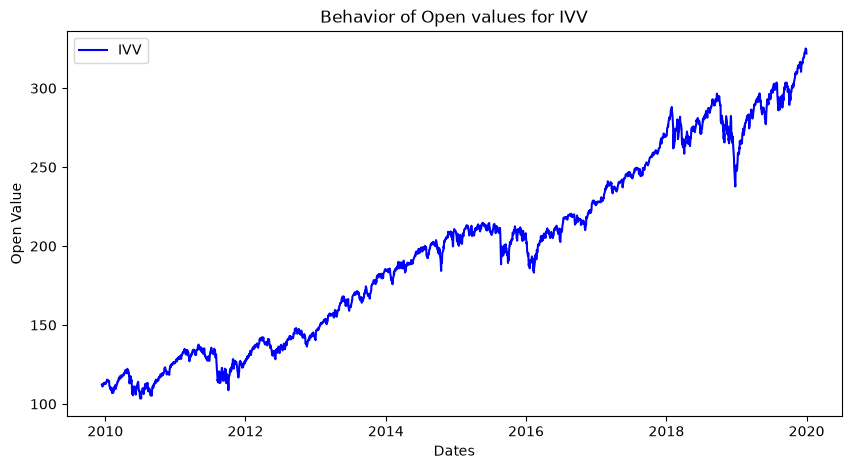

In [9]:
fig, ax = plt.subplots(figsize = (10, 5))

ax.plot(df.index, open_values, color = 'blue', label = ticker)
ax.set_ylabel('Open Value')
ax.set_xlabel('Dates')
ax.set_title('Behavior of Open values for IVV')

plt.legend()
plt.show() 

The Open price path is consistent with paper **Figure 2** (IVV panel): a long upward trend from ~110 to ~320 over 2010–2019.


### Γ Cumulative Movement 

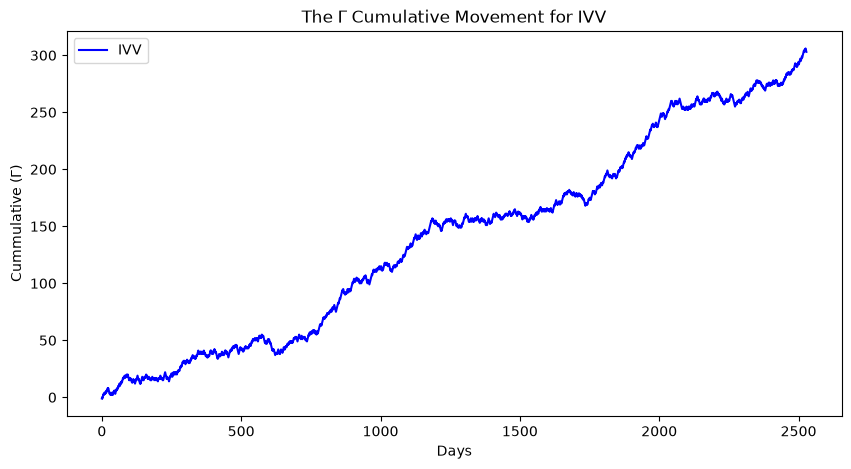

In [10]:
# Γ(t) = 1 if Open(t+1) > Open(t), else -1  (paper §2.4)
gamma = np.where(open_values < open_values.shift(-1), 1, -1).squeeze()

days = [i for i in range(len(gamma))]
cumulative_gamma = gamma.cumsum()

fig, ax = plt.subplots(figsize=(10, 5))

ax.plot(days, cumulative_gamma, color="blue", label=ticker)
ax.set_ylabel("Cumulative (Γ)")
ax.set_xlabel("Days")
ax.set_title("The Γ Cumulative Movement for IVV")

plt.legend()
plt.show()


The cumulative Γ path resembles paper **Figure 3** for IVV (net upward drift in daily open-to-open direction over the sample).


### Data Cleaning

Paper §2.6: after technical indicators, drop incomplete observations. `strategy("All")` yields more than 216 columns, many with NaNs.

**Our steps (results from the run below):**
1. Keep **216** columns by dropping those with the **most NaNs first** (e.g. `ACOS`/`ASIN`, PSAR/SUPERT long–short).
2. `dropna` remaining incomplete days → about **2529 → 2520** rows, dates **2009-12-28 → 2019-12-31**.


In [11]:
TARGET_COLS = 216

rows_before = len(df)
cols_before = df.shape[1]

# Drop columns with the most NaNs first until 216 remain
nan_counts = df.isna().sum().sort_values(ascending=False)
n_drop = max(0, df.shape[1] - TARGET_COLS)
cols_dropped_for_nan = nan_counts.index[:n_drop].tolist()
df = df.drop(columns=cols_dropped_for_nan)

print(f"Columns after NaN-priority trim: {df.shape[1]} (dropped {len(cols_dropped_for_nan)})")
print("Most-NaN columns dropped (first 10):")
print(nan_counts.head(10))

# Paper §2.6: drop days with any remaining missing values
df = df.dropna(how="any").copy()

print(f"\nRows: {rows_before} → {len(df)} (dropped {rows_before - len(df)} days)")
print(f"Cols: {cols_before} → {df.shape[1]}")
print(f"Date range: {df.index.min().date()} → {df.index.max().date()}")
print(f"Remaining missing values: {int(df.isna().sum().sum())}")
df.head()


Columns after NaN-priority trim: 216 (dropped 197)
Most-NaN columns dropped (first 10):
ASIN               2529
ACOS               2529
PSARs_0.02_0.2     1580
SUPERTs_7_3.0      1566
QQEs_14_5_4.236    1468
HILOs_13_21        1410
QQEl_14_5_4.236    1131
SUPERTl_7_3.0       969
PSARl_0.02_0.2      950
HILOl_13_21         687
dtype: int64

Rows: 2529 → 2520 (dropped 9 days)
Cols: 413 → 216
Date range: 2009-12-28 → 2019-12-31
Remaining missing values: 0


,Adj Close_IVV,Close_IVV,High_IVV,Low_IVV,Open_IVV,Volume_IVV,ABER_ZG_5_15,AD,ADD,AMATe_LR_8_21_2,...,TOS_STDEVALL_L_3,TOS_STDEVALL_U_3,TRUERANGE_1,TRUNC,TTM_TRND_6,TYPPRICE,VWAP_D,WAD,WCP,WMA_10
Date,,,,,,,,,,,,,,,,,,,,,
2009-12-28,84.269928,113.129997,113.339996,112.680000,113.279999,2157000,112.710000,1.629566e+06,226.259995,0,...,-81.565408,274.800466,0.659996,113.0,1,113.049998,113.049998,1.570000,113.069998,112.400909
2009-12-29,84.158226,112.980003,113.430000,112.919998,113.430000,1766900,112.895333,2.784413e+05,225.960007,0,...,-81.485432,274.880441,0.510002,112.0,1,113.110001,113.110001,1.120003,113.077501,112.554910
2009-12-30,84.091187,112.889999,113.000000,112.529999,112.610001,2501300,112.921333,1.608917e+06,225.779999,0,...,-81.405457,274.960416,0.470001,112.0,1,112.806666,112.806666,1.010002,112.827499,112.678909
2009-12-31,83.286713,111.809998,113.139999,111.610001,113.099998,3000900,112.794667,-6.074458e+05,223.619995,0,...,-81.325482,275.040392,1.529999,111.0,-1,112.186666,112.186666,-0.320000,112.092499,112.584727
2010-01-04,84.657310,113.650002,113.739998,112.709999,112.769997,3574200,112.903999,2.342161e+06,227.300003,0,...,-81.245506,275.120367,1.930000,113.0,1,113.366666,113.366666,1.520004,113.437500,112.826727


After cleaning we have a complete 216-feature panel (no NaNs). Min–max scaling is applied later, just before the MLP (§2.5 / model validation).


### Metric Evaluation

We use **Dispersion Ratio (DR)** from paper §2.16 as a relevance screen: higher DR ⇒ more dispersed ⇒ typically more informative. DR is defined only for **strictly positive** features.


#### Dispersion Ratio

$$
\bar{x} = \frac{1}{N}\sum_{i=1}^{N} value_i, \quad
\bar{x}_g = \left(\prod_{i=1}^{N} value_i\right)^{1/N}, \quad
DR = \frac{\bar{x}}{\bar{x}_g}
$$

$DR \ge 1$, with equality iff all sample values are identical.


In [ ]:
def get_dispersion_ratio(df: pd.DataFrame) -> pd.Series:
    """Paper §2.16 — DR only for strictly positive columns."""
    pos = df.loc[:, (df > 0).all(axis=0)]
    arithmetic_mean = pos.mean(axis=0)
    geometric_mean = np.exp(np.log(pos).mean(axis=0))
    return (arithmetic_mean / geometric_mean).sort_values(ascending=False)


In [ ]:
dr = get_dispersion_ratio(df)
print(f"Positive features used for DR: {len(dr)} / {df.shape[1]}")
print("\nTop 10 by dispersion ratio:")
print(dr.head(10).to_frame("DR"))

ohlcv = [
    c for c in ["Volume_IVV", "Adj Close_IVV", "Close_IVV", "High_IVV", "Low_IVV", "Open_IVV"]
    if c in dr.index
]
print("\nOHLCV dispersion ratios:")
print(dr.loc[ohlcv].to_frame("DR") if ohlcv else "(none in positive set)")


Among **OHLCV**, **Volume** usually has the largest DR, then **Adj Close**, while **Open / High / Low / Close** are nearly identical (~1.05). Several technical indicators can rank even higher — see the Top 10 table above. Per the paper, higher DR suggests higher relevance for feature screening.


#### LASSO 

### Model Validation

Predict Γ with the paper MLP (§2.7) under two CV setups:
- **Cross-Fold Validation** — Algorithm 1 (`shuffle=True`, $K=10$)
- **k-Cross-Fold Validation** — paper experiment generator (`StratifiedKFold`, `shuffle=False`, $K=10`)

Paper **Table 4** IVV Selected(0) median accuracy: **77.26%**. Our full-feature runs land lower (~**71–73%**), which is expected before full Algorithm 2 feature selection; the Table 5 Selected(5) proxy is much closer (~**78%**).


#### Cross-Fold Validation

Paper **Algorithm 1** (Section 2.17), with $K = 10$ folds and the MLP setup from Section 2.7.

1. Randomly shuffle the dataset  
2. Partition into $k$ groups  
3. For each group: train on the rest, evaluate on the held-out fold  
4. Average the fold accuracies  



In [14]:
# Align features with class label Γ (paper §2.4): 1 if next Open > Open, else -1
open_col = next(c for c in df.columns if c.startswith("Open"))
y = np.where(df[open_col].shift(-1) > df[open_col], 1, -1)

# Last day has no next Open — drop it (paper: dataset length decreases by one)
X = df.iloc[:-1].copy()
y = y[:-1]

# Min–max normalization (paper §2.5)
scaler = MinMaxScaler()
X_scaled = pd.DataFrame(
    scaler.fit_transform(X),
    index=X.index,
    columns=X.columns,
)

print(f"X shape: {X_scaled.shape}, y shape: {y.shape}")
print(f"Class balance: {(y == 1).sum()} up / {(y == -1).sum()} down")


X shape: (2519, 216), y shape: (2519,)
Class balance: 1410 up / 1109 down


In [15]:
def build_mlp(n_features: int, y: np.ndarray, random_state: int = 42) -> MLPClassifier:
    """MLP config from paper §2.7."""
    hidden_layer_sizes = int((n_features + len(np.unique(y))) / 2)
    return MLPClassifier(
        hidden_layer_sizes=hidden_layer_sizes,
        activation="logistic",
        solver="lbfgs",
        batch_size="auto",
        learning_rate="adaptive",
        learning_rate_init=0.03,
        max_iter=2000,
        momentum=0.2,
        random_state=random_state,
        early_stopping=False,
    )


def cross_validation(X, y, k: int = 10, random_state: int = 42):
    """
    Algorithm 1 — Cross-validation (paper §2.17)
    1. Randomly shuffle the dataset
    2. Partition into k groups
    3. For each group: train on the rest, evaluate on the test fold
    4. Average accuracies
    """
    X = np.asarray(X)
    y = np.asarray(y)

    # Step 1–2: shuffle + partition (stratified to keep class balance)
    cv = StratifiedKFold(n_splits=k, shuffle=True, random_state=random_state)
    fold_accuracies = []

    # Step 3–7: for each unique group
    for fold, (train_idx, test_idx) in enumerate(cv.split(X, y), start=1):
        X_train, X_test = X[train_idx], X[test_idx]
        y_train, y_test = y[train_idx], y[test_idx]

        model = build_mlp(X_train.shape[1], y_train, random_state=random_state)
        model.fit(X_train, y_train)
        acc = accuracy_score(y_test, model.predict(X_test))
        fold_accuracies.append(acc)
        print(f"Fold {fold:2d}: accuracy = {acc:.4f}")

    # Step 8: average accuracies
    mean_acc = float(np.mean(fold_accuracies))
    print(f"\nMean accuracy over {k} folds: {mean_acc:.4f} ({100 * mean_acc:.2f}%)")
    return fold_accuracies, mean_acc


In [16]:
fold_accuracies, mean_accuracy = cross_validation(X_scaled, y, k=10)


Fold  1: accuracy = 0.7103
Fold  2: accuracy = 0.7063
Fold  3: accuracy = 0.6905
Fold  4: accuracy = 0.7381
Fold  5: accuracy = 0.7778
Fold  6: accuracy = 0.7619
Fold  7: accuracy = 0.7698
Fold  8: accuracy = 0.6627
Fold  9: accuracy = 0.7381
Fold 10: accuracy = 0.7649

Mean accuracy over 10 folds: 0.7320 (73.20%)


From this run (Algorithm 1, shuffle=True): **mean accuracy ≈ 73.20%** across 10 folds (fold range ~66–78%). Paper Table 4 reports **median** accuracy for Selected(0) as **77.26%** — not directly comparable to this shuffled mean, and we have not yet applied Algorithm 2 feature selection.


#### k-Cross-Fold Validation

Same evaluation with paper’s experimental CV generator (`StratifiedKFold`, $K = 10$, `shuffle=False`).



In [17]:
def k_cross_validation(X, y, k: int = 10, random_state: int = 42):
    """K-fold CV as in paper §2.7 (StratifiedKFold, shuffle=False)."""
    X = np.asarray(X)
    y = np.asarray(y)
    cv_generator = StratifiedKFold(n_splits=k, shuffle=False)

    fold_accuracies = []
    for fold, (train_idx, test_idx) in enumerate(cv_generator.split(X, y), start=1):
        X_train, X_test = X[train_idx], X[test_idx]
        y_train, y_test = y[train_idx], y[test_idx]

        model = build_mlp(X_train.shape[1], y_train, random_state=random_state)
        model.fit(X_train, y_train)
        acc = accuracy_score(y_test, model.predict(X_test))
        fold_accuracies.append(acc)
        print(f"Fold {fold:2d}: accuracy = {acc:.4f}")

    mean_acc = float(np.mean(fold_accuracies))
    median_acc = float(np.median(fold_accuracies))
    print(f"\nMean accuracy:   {mean_acc:.4f} ({100 * mean_acc:.2f}%)")
    print(f"Median accuracy: {median_acc:.4f} ({100 * median_acc:.2f}%)")
    return fold_accuracies, mean_acc, median_acc


kfold_accuracies, kfold_mean, kfold_median = k_cross_validation(X_scaled, y, k=10)


Fold  1: accuracy = 0.7103
Fold  2: accuracy = 0.7103
Fold  3: accuracy = 0.7103
Fold  4: accuracy = 0.6825
Fold  5: accuracy = 0.7262
Fold  6: accuracy = 0.6587
Fold  7: accuracy = 0.6865
Fold  8: accuracy = 0.7222
Fold  9: accuracy = 0.7302
Fold 10: accuracy = 0.7052

Mean accuracy:   0.7042 (70.42%)
Median accuracy: 0.7103 (71.03%)


From this run (`shuffle=False`): **mean ≈ 70.42%**, **median ≈ 71.03%**. Paper Table 4 Selected(0) median is **77.26%** (gap ≈ **−6.2 pp**). Likely drivers: different Pandas-TA feature set / cleaning choices, and no Algorithm 2 salience filtering yet.


#### Compare to Paper Table 4 (IVV)

Re-run $K$-fold MLP (`shuffle=False`) on:
1. **Selected(0)** — all 216 cleaned features  
2. **Table 5 Selected(5)** — paper’s published IVV feature names (subset present in our columns)

Results from the latest notebook run:

| Set | Features used | Our median % | Paper Table 4 % | Delta |
|---|---:|---:|---:|---:|
| Selected(0) | 216 | 71.03 | 77.26 | −6.23 |
| Table 5 Selected(5) | 7 / 9 | 77.98 | 78.54 | −0.56 |

`WILLR_14` and `STOCHRSIk_14_14_3_3` were missing after our NaN-priority trim to 216 columns. Even so, the Table 5 proxy is close to the paper’s Selected(5) accuracy.


In [18]:
TABLE4_IVV = {
    0: 77.26,
    1: 77.64,
    2: 77.63,
    3: 77.63,
    4: 77.78,
    5: 78.54,
    6: 71.05,
}

TABLE5_IVV = [
    "BBP_5_2.0", "BOP", "DEC_1", "INC_1", "J_9_3",
    "PVR", "TTM_TRND_6", "WILLR_14", "STOCHRSIk_14_14_3_3",
]

print("=== Selected(0): all current features ===")
acc0, mean0, median0 = k_cross_validation(X_scaled, y, k=10)
print(f"Paper Table 4 Selected(0): {TABLE4_IVV[0]:.2f}%")
print(f"Ours median: {100 * median0:.2f}% | delta: {100 * median0 - TABLE4_IVV[0]:+.2f}\n")

present5 = [c for c in TABLE5_IVV if c in X_scaled.columns]
missing5 = [c for c in TABLE5_IVV if c not in X_scaled.columns]
print(f"Paper Selected(5) features present: {len(present5)}/{len(TABLE5_IVV)}")
if missing5:
    print(f"Missing: {missing5}")

if present5:
    print("\n=== Paper Table 5 feature list (proxy for Selected(5)) ===")
    acc5, mean5, median5 = k_cross_validation(X_scaled[present5], y, k=10)
    print(f"Paper Table 4 Selected(5): {TABLE4_IVV[5]:.2f}%")
    print(f"Ours median: {100 * median5:.2f}% | delta: {100 * median5 - TABLE4_IVV[5]:+.2f}")

comparison = pd.DataFrame([
    {
        "set": "Selected(0)",
        "n_features": X_scaled.shape[1],
        "our_median_%": round(100 * median0, 2),
        "paper_%": TABLE4_IVV[0],
        "delta": round(100 * median0 - TABLE4_IVV[0], 2),
    },
])
if present5:
    comparison = pd.concat([
        comparison,
        pd.DataFrame([{
            "set": "Table5 Selected(5)",
            "n_features": len(present5),
            "our_median_%": round(100 * median5, 2),
            "paper_%": TABLE4_IVV[5],
            "delta": round(100 * median5 - TABLE4_IVV[5], 2),
        }]),
    ], ignore_index=True)
comparison


=== Selected(0): all current features ===
Fold  1: accuracy = 0.7103
Fold  2: accuracy = 0.7103
Fold  3: accuracy = 0.7103
Fold  4: accuracy = 0.6825
Fold  5: accuracy = 0.7262
Fold  6: accuracy = 0.6587
Fold  7: accuracy = 0.6865
Fold  8: accuracy = 0.7222
Fold  9: accuracy = 0.7302
Fold 10: accuracy = 0.7052

Mean accuracy:   0.7042 (70.42%)
Median accuracy: 0.7103 (71.03%)
Paper Table 4 Selected(0): 77.26%
Ours median: 71.03% | delta: -6.23

Paper Selected(5) features present: 7/9
Missing: ['WILLR_14', 'STOCHRSIk_14_14_3_3']

=== Paper Table 5 feature list (proxy for Selected(5)) ===
Fold  1: accuracy = 0.7659
Fold  2: accuracy = 0.8294
Fold  3: accuracy = 0.7817
Fold  4: accuracy = 0.7738
Fold  5: accuracy = 0.8175
Fold  6: accuracy = 0.7976
Fold  7: accuracy = 0.7778
Fold  8: accuracy = 0.7698
Fold  9: accuracy = 0.7937
Fold 10: accuracy = 0.7769

Mean accuracy:   0.7884 (78.84%)
Median accuracy: 0.7798 (77.98%)
Paper Table 4 Selected(5): 78.54%
Ours median: 77.98% | delta: -0.56


,set,n_features,our_median_%,paper_%,delta
0,Selected(0),216,71.03,77.26,-6.23
1,Table5 Selected(5),7,77.98,78.54,-0.56


## Part 2: Evaluating One Particular Type of Alternative Data 

In [19]:
## TODO: will choose the Twitter and TwitStock data for analysis 